Some very bad and simplified predictions for time series data 

In [58]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
cleaned_df = pd.read_csv("Data/Japan_Visitor_Data.csv")
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"])
cleaned_df = cleaned_df[["Year", "Month", "Date", "Daily Visitors"]]
cleaned_df

,Year,Month,Date,Daily Visitors
0,1996,Jan,1996-01-01,8906.000000
1,1996,Feb,1996-02-01,9781.620690
2,1996,Mar,1996-03-01,10022.645161
3,1996,Apr,1996-04-01,10976.766667
4,1996,May,1996-05-01,10521.161290
...,...,...,...,...
356,2025,Sep,2025-09-01,108907.600000
357,2025,Oct,2025-10-01,125694.322581
358,2025,Nov,2025-11-01,117273.166667
359,2025,Dec,2025-12-01,116700.000000


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/874996051.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


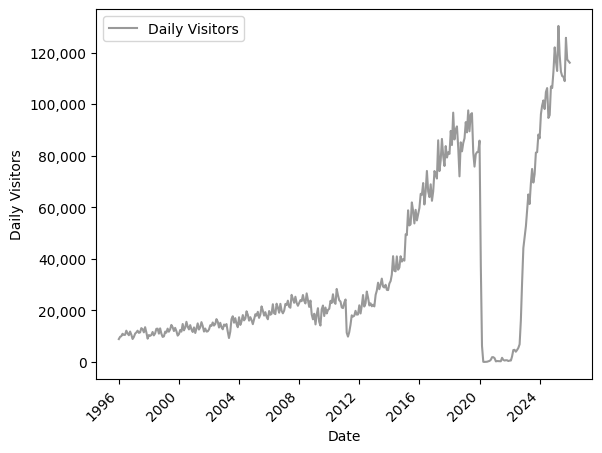

In [59]:
# First test - naive method
sns.lineplot(data = cleaned_df, x = "Date", y = "Daily Visitors", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right");

In [74]:
# using the last 24 months (two years)
cutoff = 24
x_naive = cleaned_df.copy()
x_naive["Daily Visitors"].iloc[-cutoff:] = cleaned_df["Daily Visitors"].iloc[-cutoff-1]
print(x_naive.to_string())

     Year Month       Date  Daily Visitors
0    1996   Jan 1996-01-01     8906.000000
1    1996   Feb 1996-02-01     9781.620690
2    1996   Mar 1996-03-01    10022.645161
3    1996   Apr 1996-04-01    10976.766667
4    1996   May 1996-05-01    10521.161290
5    1996   Jun 1996-06-01    10556.633333
6    1996   Jul 1996-07-01    12163.548387
7    1996   Aug 1996-08-01    11129.677419
8    1996   Sep 1996-09-01    10396.033333
9    1996   Oct 1996-10-01    11833.580645
10   1996   Nov 1996-11-01    10551.700000
11   1996   Dec 1996-12-01     8939.903226
12   1997   Jan 1997-01-01     9746.709677
13   1997   Feb 1997-02-01    11047.071429
14   1997   Mar 1997-03-01    11458.967742
15   1997   Apr 1997-04-01    12162.500000
16   1997   May 1997-05-01    11321.322581
17   1997   Jun 1997-06-01    11502.333333
18   1997   Jul 1997-07-01    13145.483871
19   1997   Aug 1997-08-01    12743.741935
20   1997   Sep 1997-09-01    11512.733333
21   1997   Oct 1997-10-01    13523.709677
22   1997  

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/2138884679.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_naive["Daily Visitors"].iloc[-cutoff:] = cleaned_df["Daily Visitors"].iloc[-cutoff-1]


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/1624490313.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


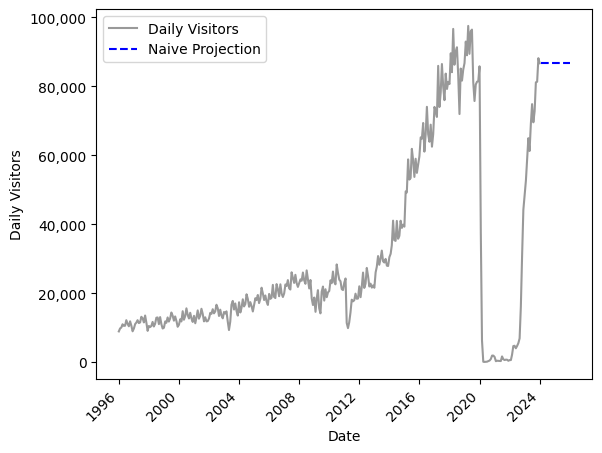

In [75]:
# Graphing the naive method of doing things
sns.lineplot(data = x_naive.iloc[:-cutoff], x = "Date", y = "Daily Visitors", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = x_naive.iloc[-cutoff:, :], x = "Date", y = "Daily Visitors", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Naive Projection")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right");

In [84]:
x_mean = cleaned_df.copy()
x_mean["Daily Visitors"].iloc[-cutoff:]  = x_mean["Daily Visitors"].iloc[0:-cutoff].mean()
print(x_mean)

     Year Month       Date  Daily Visitors
0    1996   Jan 1996-01-01     8906.000000
1    1996   Feb 1996-02-01     9781.620690
2    1996   Mar 1996-03-01    10022.645161
3    1996   Apr 1996-04-01    10976.766667
4    1996   May 1996-05-01    10521.161290
..    ...   ...        ...             ...
356  2025   Sep 2025-09-01    29112.547210
357  2025   Oct 2025-10-01    29112.547210
358  2025   Nov 2025-11-01    29112.547210
359  2025   Dec 2025-12-01    29112.547210
360  2026   Jan 2026-01-01    29112.547210

[361 rows x 4 columns]


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/1904174503.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_mean["Daily Visitors"].iloc[-cutoff:]  = x_mean["Daily Visitors"].iloc[0:-cutoff].mean()


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/1491912503.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

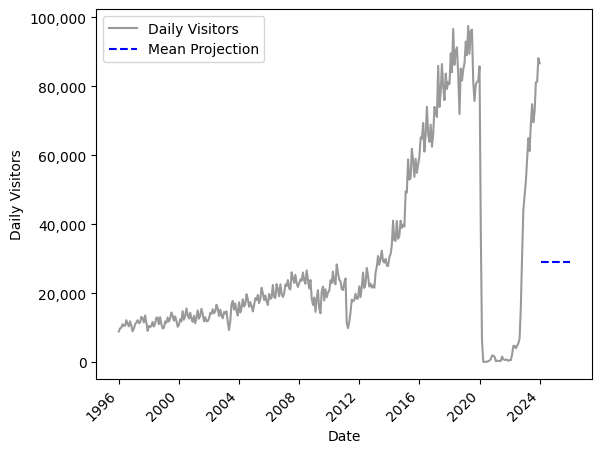

In [85]:
sns.lineplot(data = x_mean.iloc[:-cutoff], x = "Date", y = "Daily Visitors", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = x_mean.iloc[-cutoff:], x = "Date", y = "Daily Visitors", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Mean Projection")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/534459900.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_seasonal["Daily Visitors"].iloc[-24:-12] = cleaned_df["Daily Visitors"].iloc[-36:-24]
/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/534459900.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_seasonal["Daily Visitors"].iloc[-12:] = cleaned_df["Daily Visitors"].iloc[-36:-24]
/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/534459900.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format

     Year Month       Date  Daily Visitors
0    1996   Jan 1996-01-01     8906.000000
1    1996   Feb 1996-02-01     9781.620690
2    1996   Mar 1996-03-01    10022.645161
3    1996   Apr 1996-04-01    10976.766667
4    1996   May 1996-05-01    10521.161290
..    ...   ...        ...             ...
356  2025   Sep 2025-09-01    72814.733333
357  2025   Oct 2025-10-01    81181.387097
358  2025   Nov 2025-11-01    81363.000000
359  2025   Dec 2025-12-01    88197.258065
360  2026   Jan 2026-01-01    86725.096774

[361 rows x 4 columns]


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

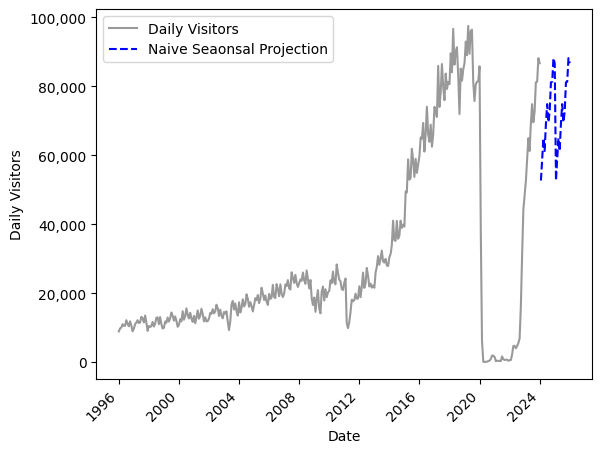

In [98]:
x_seasonal = cleaned_df.copy()
x_seasonal["Daily Visitors"].iloc[-24:-12] = cleaned_df["Daily Visitors"].iloc[-36:-24]
x_seasonal["Daily Visitors"].iloc[-12:] = cleaned_df["Daily Visitors"].iloc[-36:-24]
print(x_seasonal)

sns.lineplot(data = x_seasonal.iloc[:-cutoff], x = "Date", y = "Daily Visitors", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = x_seasonal.iloc[-cutoff:], x = "Date", y = "Daily Visitors", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Naive Seaonsal Projection")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/998706830.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([16436., 16801., 17167., 17532., 17897., 18262., 18628., 18993.,
        19358., 19723., 20089., 20454.]),
 [Text(16436.0, 0, '2015'),
  Text(16801.0, 0, '2016'),
  Text(17167.0, 0, '2017'),
  Text(17532.0, 0, '2018'),
  Text(17897.0, 0, '2019'),
  Text(18262.0, 0, '2020'),
  Text(18628.0, 0, '2021'),
  Text(18993.0, 0, '2022'),
  Text(19358.0, 0, '2023'),
  Text(19723.0, 0, '2024'),
  Text(20089.0, 0, '2025'),
  Text(20454.0, 0, '2026')])

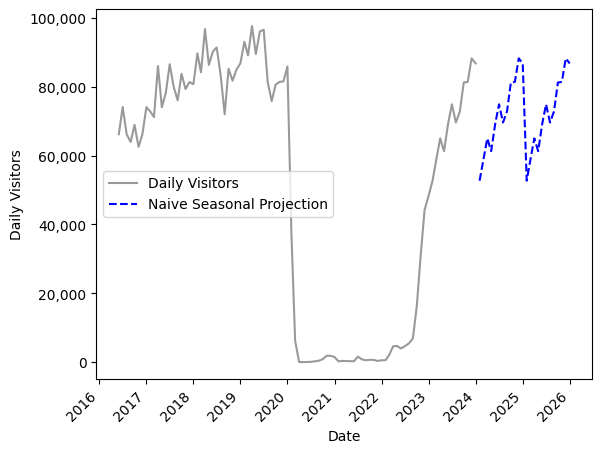

In [100]:
sns.lineplot(data = x_seasonal.iloc[245:-cutoff], x = "Date", y = "Daily Visitors", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = x_seasonal.iloc[-cutoff:], x = "Date", y = "Daily Visitors", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Naive Seasonal Projection")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/3972322819.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_extrapolate["Daily Visitors"].iloc[-cutoff:] = extrapolated
/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/3972322819.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([16436., 16801., 17167., 17532., 17897., 18262., 18628., 18993.,
        19358., 19723., 20089., 20454.]),
 [Text(16436.0, 0, '2015'),
  Text(16801.0, 0, '2016'),
  Text(17167.0, 0, '2017'),
  Text(17532.0, 0, '2018'),
  Text(17897.0, 0, '2019'),
  Text(18262.0, 0, '2020'),
  Text(18628.0, 0, '2021'),
  Text(18993.0, 0, '2022'),
  Text(19358.0, 0, '2023'),
  Text(19723.0, 0, '2024'),
  Text(20089.0, 0, '2025'),
  Text(20454.0, 0, '2026')])

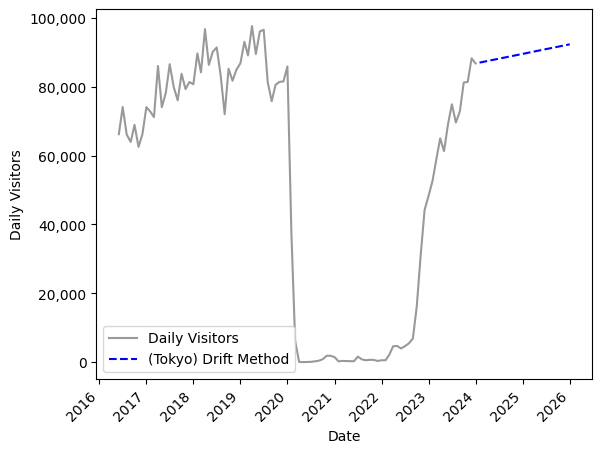

In [117]:
# Lastly, the (Tokyo) drift method
import numpy as np
increment = (cleaned_df["Daily Visitors"].iloc[-cutoff - 1,] - cleaned_df["Daily Visitors"].iloc[0,])/(len(cleaned_df) - cutoff)

extrapolated = np.arange(cleaned_df["Daily Visitors"].iloc[-cutoff - 1,] + increment, \
                         cleaned_df["Daily Visitors"].iloc[-cutoff - 1,] + increment * cutoff+1, increment)
x_extrapolate = cleaned_df.copy()
x_extrapolate["Daily Visitors"].iloc[-cutoff:] = extrapolated

sns.lineplot(data = x_extrapolate.iloc[245:-24,:], x = "Date", y = "Daily Visitors", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = x_extrapolate.iloc[-24:, :], x = "Date", y = "Daily Visitors", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "(Tokyo) Drift Method")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_8674/3438944342.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


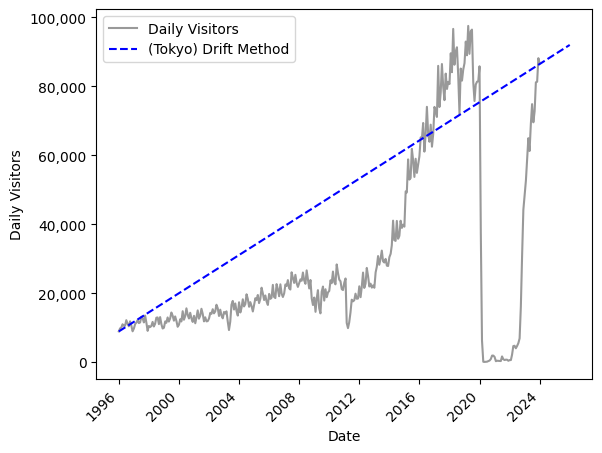

In [123]:
# Lastly, the (Tokyo) drift method
extrapolated = np.arange(cleaned_df["Daily Visitors"].iloc[0], \
                         cleaned_df["Daily Visitors"].iloc[0] + increment * len(cleaned_df), increment)
x_extrapolate["Temp Trend"] = extrapolated

sns.lineplot(data = x_extrapolate.iloc[:-cutoff], x = "Date", y = "Daily Visitors", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = x_extrapolate, x = "Date", y = "Temp Trend", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "(Tokyo) Drift Method")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right");

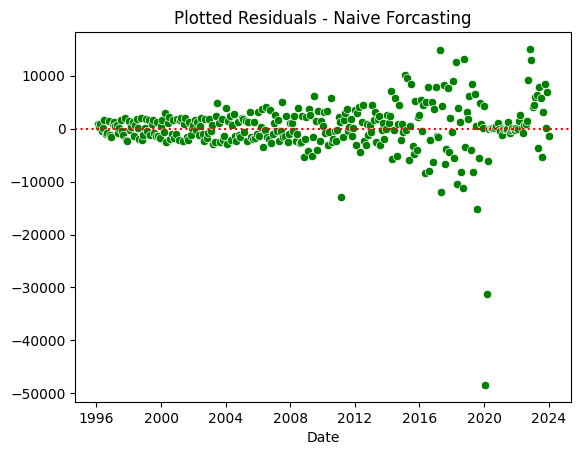

In [125]:
# Testing Residuals for the naive method

y_hat = cleaned_df["Daily Visitors"].to_numpy()[0:-1-cutoff]
y = cleaned_df["Daily Visitors"].to_numpy()[1:-cutoff]
resid = y - y_hat
sns.scatterplot(x = cleaned_df["Date"][1:-cutoff], y = resid, color = "g")
plt.title(label = "Plotted Residuals - Naive Forcasting")
plt.axhline(y = 0, color='red', linestyle=':') 
plt.show()


It's good that the residuals appear to be unbiased, but they are demonstrating hetroscedasticity (changing variance) over the long-run. I want to run a log transform on the data and see if that fixes things. Epic fail - I'm just going to redo this with a box-cox transformation

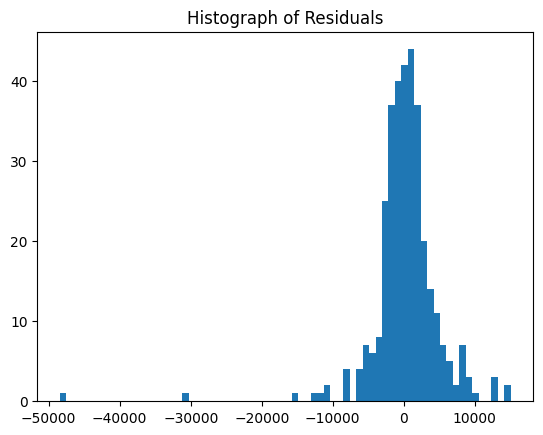

In [126]:
plt.hist(x = resid, bins = 70)
plt.title(label = "Histograph of Residuals")
plt.show()

Looks pretty, good, maybe a bit too lage of a tail to the left (however, it somehow balances out the stuff on the right)

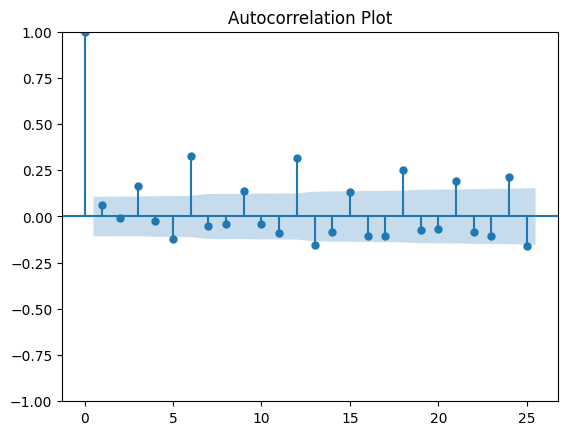

In [127]:
from statsmodels.graphics.tsaplots import plot_acf

# 'data' should be a 1D array or pandas Series
plot_acf(resid, lags = 25)
plt.title(label = "Autocorrelation Plot")
plt.show()

Looks pretty good, outside of first part (correlation of residual with itself), the autocorrelation appears to be pretty random
## Next Step: Calculating Standard Deviation of residuals
We now want to calcualte the standard deviation of the residuals

$\hat{\sigma} = \sqrt{\frac{1}{T-K-M}\sum{e_t^2}}$

Where T is number of times, K is number of parameters estimated in the forecasting method, and M is the number of missing values in the residuals (M = 1 for naive forecast because we don't forecast first observation)

In [68]:
std = np.sqrt((1/343)* np.sum(np.square(resid)))
std

# Note - don't think this actually works because residuals are not normal. They increase as they go...

5092.334516048711